In [60]:
!pip install torch torch-geometric pandas numpy scikit-learn folium -q

Create Dataset(5000+Nodes)

In [61]:
import pandas as pd
import numpy as np

np.random.seed(42)

types = ["waterfall", "temple", "beach", "monument", "hill", "lake"]

num_places = 5000
num_users = 200

# Places
places = pd.DataFrame({
    "id": range(num_places),
    "type": np.random.choice(types, num_places),
    "lat": np.random.uniform(10, 30, num_places),
    "lon": np.random.uniform(70, 90, num_places),
    "rating": np.random.uniform(3, 5, num_places)
})

# Users
users = pd.DataFrame({
    "id": range(num_users)
})

User-Place Interactions

In [62]:
interactions = []

for user in users["id"]:
    visited = np.random.choice(places["id"], size=10, replace=False)
    for p in visited:
        interactions.append([user, p])

interactions = pd.DataFrame(interactions, columns=["user", "place"])

Encode Features

In [63]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
places["type_enc"] = le.fit_transform(places["type"])

place_features = places[["type_enc", "lat", "lon", "rating"]].values
user_features = np.zeros((num_users, 4))  # simple

features = np.vstack([user_features, place_features])

Building Graph (BiPartite=User-Place,Place-Place)

In [64]:
import torch
from sklearn.neighbors import NearestNeighbors

edges = []

# user → place edges
for _, row in interactions.iterrows():
    u = row["user"]
    p = row["place"] + num_users
    edges.append([u, p])
    edges.append([p, u])

# place → place (nearby)
coords = places[["lat", "lon"]].values
nbrs = NearestNeighbors(n_neighbors=10).fit(coords)
_, indices = nbrs.kneighbors(coords)

for i in range(num_places):
    for j in indices[i]:
        edges.append([i+num_users, j+num_users])

edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
x = torch.tensor(features, dtype=torch.float)

Graph Data

In [65]:
from torch_geometric.data import Data

data = Data(x=x, edge_index=edge_index)

GAT Model

In [66]:
import torch.nn as nn
from torch_geometric.nn import GATConv

class GAT(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GATConv(4, 64, heads=2)#2 attentio heads
        self.conv2 = GATConv(128, 64)#64*2=128 input

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index)
        return x

Training (Unsupervised Embeddings)

In [67]:
model = GAT()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

for epoch in range(30):
    optimizer.zero_grad()
    emb = model(data.x, data.edge_index)
    loss = (emb**2).mean()
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print("Epoch", epoch, "Loss:", loss.item())

Epoch 0 Loss: 53.59130859375
Epoch 10 Loss: 1.7528014183044434
Epoch 20 Loss: 0.552351713180542


Embedding

In [68]:
model.eval()
emb = model(data.x, data.edge_index)
embeddings = emb.detach().numpy()

Explainability

In [69]:
def explain(user_id, place_id):
    place = places.iloc[place_id]

    visited = interactions[interactions["user"] == user_id]["place"].values

    reasons = []

    for v in visited:
        visited_place = places.iloc[v]

        if visited_place["type"] == place["type"]:
            reasons.append(f"Similar type: {place['type']}")

        dist = abs(visited_place["lat"] - place["lat"]) + abs(visited_place["lon"] - place["lon"])
        if dist < 2:
            reasons.append("Nearby to visited place")

    if len(reasons) == 0:
        reasons.append("High similarity in graph embeddings")

    return reasons

Recommendation

In [79]:
def recommend_for_user(user_id, top_k=3):
    from sklearn.metrics.pairwise import cosine_similarity
    from collections import Counter

    # 🔹 user embedding
    user_emb = embeddings[user_id]

    # 🔹 similarity
    scores = cosine_similarity([user_emb], embeddings)[0]
    place_scores = scores[num_users:]

    # 🔹 visited places
    visited = interactions[interactions["user"] == user_id]["place"].values

    # 🔥 MULTI-TYPE WEIGHTED BOOST
    if len(visited) > 0:
        visited_types = [places.iloc[idx]["type"] for idx in visited]
        type_counts = Counter(visited_types)

        total = sum(type_counts.values())

        # normalize frequencies
        type_weights = {t: count/total for t, count in type_counts.items()}

        # apply weighted boost
        for i in range(len(place_scores)):
            place_type = places.iloc[i]["type"]
            if place_type in type_weights:
                place_scores[i] += 0.1 * type_weights[place_type]

    # 🔹 top K
    top_idx = place_scores.argsort()[-top_k:][::-1]

    print("\nRecommended Places:\n")

    for idx in top_idx:
        row = places.iloc[idx]

        print(f"Place ID: {idx} | {row['type']} | Rating {row['rating']:.2f} | "
              f"({row['lat']:.2f},{row['lon']:.2f})")

        reasons = explain(user_id, idx)
        print("Reason:", ", ".join(reasons))
        print()

    return top_idx

Map Visualization

In [71]:
import folium

def show_map(indices):
    m = folium.Map(location=[20, 78], zoom_start=5)

    for idx in indices:
        row = places.iloc[idx]
        folium.Marker(
            location=[row["lat"], row["lon"]],
            popup=row["type"]
        ).add_to(m)

    return m

UI

In [87]:
user_id = int(input("Enter user id (0-199): "))

rec = recommend_for_user(user_id)
show_map(rec)

Enter user id (0-199): 2

Recommended Places:

Place ID: 4033 | monument | Rating 4.61 | (13.88,85.80)
Reason: Similar type: monument, Similar type: monument, Similar type: monument

Place ID: 250 | monument | Rating 3.11 | (12.94,86.09)
Reason: Similar type: monument, Similar type: monument, Similar type: monument

Place ID: 2284 | monument | Rating 3.93 | (23.00,89.53)
Reason: Nearby to visited place, Similar type: monument, Similar type: monument, Similar type: monument



Graph Visualisation

In [73]:
import networkx as nx
import matplotlib.pyplot as plt

def visualize_graph_interactive():

    total_nodes = num_users + num_places
    print(f"Total nodes in graph: {total_nodes}")

    # user input
    n = int(input("Enter number of nodes to visualize (suggest: 20–100): "))

    if n > total_nodes:
        print("Too large! Showing max possible nodes.")
        n = total_nodes

    G = nx.Graph()

    # add nodes
    for i in range(n):
        if i < num_users:
            G.add_node(i, label="User")
        else:
            G.add_node(i, label=places.iloc[i - num_users]["type"])

    # add edges (limited)
    edges_np = edge_index.numpy()
    edge_count = 0

    for i in range(edges_np.shape[1]):
        u, v = edges_np[:, i]

        if u < n and v < n:
            G.add_edge(u, v)
            edge_count += 1

        if edge_count > 200:
            break

    # color nodes
    colors = []
    for node in G.nodes():
        if node < num_users:
            colors.append("red")   # users
        else:
            colors.append("blue")  # places

    plt.figure(figsize=(8,6))
    pos = nx.spring_layout(G)

    nx.draw(G, pos,
            node_color=colors,
            with_labels=True,
            node_size=300,
            font_size=8)

    plt.title(f"Graph Visualization ({n} Nodes)")
    plt.show()

Total nodes in graph: 5200
Enter number of nodes to visualize (suggest: 20–100): 500


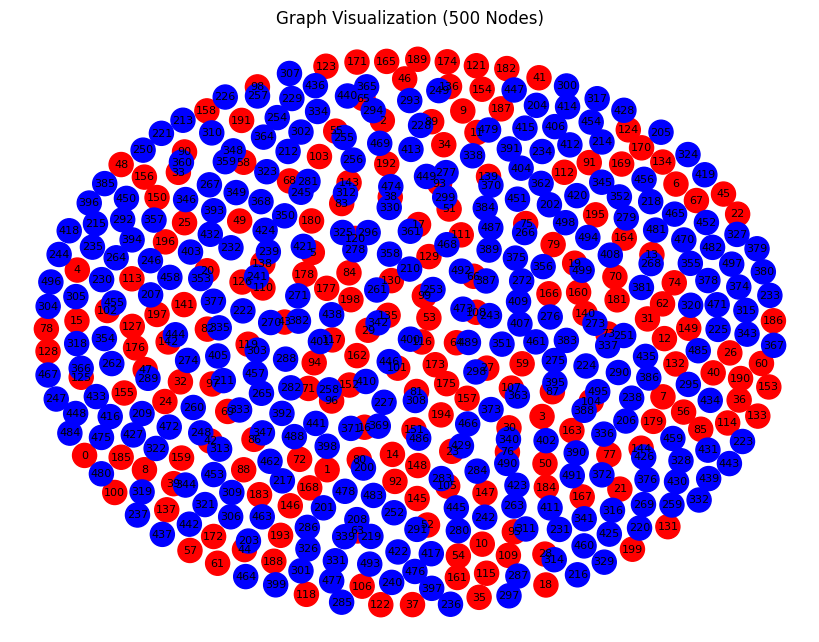

In [85]:
visualize_graph_interactive()

Additional

In [75]:
def show_visited_with_scores(user_id):
    from sklearn.metrics.pairwise import cosine_similarity

    # 🔹 get user embedding
    user_emb = embeddings[user_id]

    # 🔹 get all similarities (user vs all nodes)
    scores = cosine_similarity([user_emb], embeddings)[0]

    # 🔹 keep only place scores
    place_scores = scores[num_users:]

    # 🔹 get visited places
    visited = interactions[interactions["user"] == user_id]["place"].values

    if len(visited) == 0:
        print("No visited places for this user")
        return

    print(f"\nVisited Places for User {user_id}:\n")

    for idx in visited:
        row = places.iloc[idx]
        score = place_scores[idx]

        print(f"Place ID: {idx} | {row['type']} | Rating {row['rating']:.2f} | "
              f"({row['lat']:.2f},{row['lon']:.2f}) | "
              f"Similarity: {score:.4f}")

In [86]:
user_id = int(input("Enter user id: "))
show_visited_with_scores(user_id)

Enter user id: 2

Visited Places for User 2:

Place ID: 4913 | lake | Rating 3.64 | (15.10,88.33) | Similarity: 1.0000
Place ID: 4015 | beach | Rating 4.59 | (15.95,89.17) | Similarity: 1.0000
Place ID: 3038 | waterfall | Rating 3.37 | (10.75,86.68) | Similarity: 1.0000
Place ID: 2590 | lake | Rating 3.63 | (17.17,77.75) | Similarity: 1.0000
Place ID: 2147 | hill | Rating 3.05 | (26.88,76.89) | Similarity: 1.0000
Place ID: 1236 | hill | Rating 4.65 | (21.44,89.78) | Similarity: 1.0000
Place ID: 94 | monument | Rating 4.21 | (14.87,89.51) | Similarity: 1.0000
Place ID: 3710 | beach | Rating 4.78 | (26.62,74.85) | Similarity: 1.0000
Place ID: 1860 | monument | Rating 4.91 | (28.18,75.60) | Similarity: 0.9999
Place ID: 739 | monument | Rating 4.63 | (15.41,84.20) | Similarity: 1.0000
